In [47]:
from tkinter import Grid
from typing import Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report, balanced_accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

In [36]:


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)


MAX_SAMPLES_DATA = 100000


def reduce_dataset(df: pd.DataFrame, classification=True) -> pd.DataFrame:
    new_df = df.copy()

    new_df = new_df[new_df["CANCELLED"] == 0]

    if MAX_SAMPLES_DATA > 0:
        new_df = new_df.sample(n=MAX_SAMPLES_DATA, random_state=42)

    # Add new Rows
    delay_cols = [
        "DEPARTURE_DELAY",
        "ARRIVAL_DELAY",
        "SECURITY_DELAY",
        "AIRLINE_DELAY",
        "LATE_AIRCRAFT_DELAY",
        "WEATHER_DELAY",
        "AIR_SYSTEM_DELAY",
    ]

    delays = new_df[delay_cols].fillna(0)


    # Ich möchte wissen ob ich meinen Anschluss Flug schaffe ohne zeitlichen Druck
    if classification:
        new_df["DELAY"] = (
            delays["ARRIVAL_DELAY"] > 0
        )
    else:
        new_df["DELAY"] = delays["ARRIVAL_DELAY"]
    # Remove not needed Rows
    new_df.drop(columns=["YEAR"], inplace=True)
    new_df.drop(columns=["SCHEDULED_DEPARTURE"], inplace=True)
    new_df.drop(columns=["DEPARTURE_TIME"], inplace=True)
    new_df.drop(columns=["DEPARTURE_DELAY"], inplace=True)
    new_df.drop(columns=["TAXI_OUT"], inplace=True)
    new_df.drop(columns=["TAXI_IN"], inplace=True)
    new_df.drop(columns=["WHEELS_OFF"], inplace=True)
    new_df.drop(columns=["WHEELS_ON"], inplace=True)
    new_df.drop(columns=["ELAPSED_TIME"], inplace=True)
    new_df.drop(columns=["AIR_TIME"], inplace=True)
    new_df.drop(columns=["ARRIVAL_TIME"], inplace=True)
    new_df.drop(columns=["AIRLINE_DELAY"], inplace=True)
    new_df.drop(columns=["LATE_AIRCRAFT_DELAY"], inplace=True)
    new_df.drop(columns=["DIVERTED"], inplace=True)
    new_df.drop(columns=["CANCELLED"], inplace=True)
    new_df.drop(columns=["CANCELLATION_REASON"], inplace=True)
    new_df.drop(columns=["ARRIVAL_DELAY"], inplace=True)
    new_df.drop(columns=["SECURITY_DELAY"], inplace=True)
    new_df.drop(columns=["WEATHER_DELAY"], inplace=True)
    new_df.drop(columns=["AIR_SYSTEM_DELAY"], inplace=True)
    new_df.drop(columns=["SCHEDULED_ARRIVAL"], inplace=True)
    new_df.drop(columns=["DISTANCE"], inplace=True)
    new_df.drop(columns=["SCHEDULED_TIME"], inplace=True)
    new_df.drop(columns=["TAIL_NUMBER"], inplace=True)
    new_df.drop(columns=["MONTH"], inplace=True)
    new_df.drop(columns=["DAY"], inplace=True)

    return new_df


def describe_dataset(dataset: pd.DataFrame, path: str):
    print(f"DESCRIBE========={path}")
    print(dataset.describe())
    print("HEAD=========")
    print(dataset.head())
    print("TAIL=========")
    print(dataset.tail())
    print("==============")

def load_dataset(path: str, classification=True) -> pd.DataFrame:
    dataset = pd.read_csv(path, low_memory=False)
    dataset = reduce_dataset(dataset, classification)
    describe_dataset(dataset, path)
    return dataset


ds_flights_classification = load_dataset("./data/flights.csv")
ds_flights_regression = load_dataset("./data/flights.csv", False)

DESCRIBE=========./data/flights.csv
       DAY_OF_WEEK  FLIGHT_NUMBER
count    100000.00      100000.00
mean          3.94        2173.72
std           1.98        1758.13
min           1.00           1.00
25%           2.00         728.00
50%           4.00        1696.00
75%           6.00        3226.00
max           7.00        7438.00
HEAD=========
         DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER ORIGIN_AIRPORT  \
3679572            1      MQ           3558            ABI   
5202464            6      DL           1436            DTW   
381725             1      DL           1097            RDU   
4296182            5      UA           1135            ORD   
307995             3      MQ           3015            BTR   

        DESTINATION_AIRPORT  DELAY  
3679572                 DFW  False  
5202464                 BWI   True  
381725                  LAX  False  
4296182                 DSM  False  
307995                  DFW  False  
TAIL=========
         DAY_OF_WEEK AIRLINE  FLIGH

### Display the Data in a pairplot to understand it

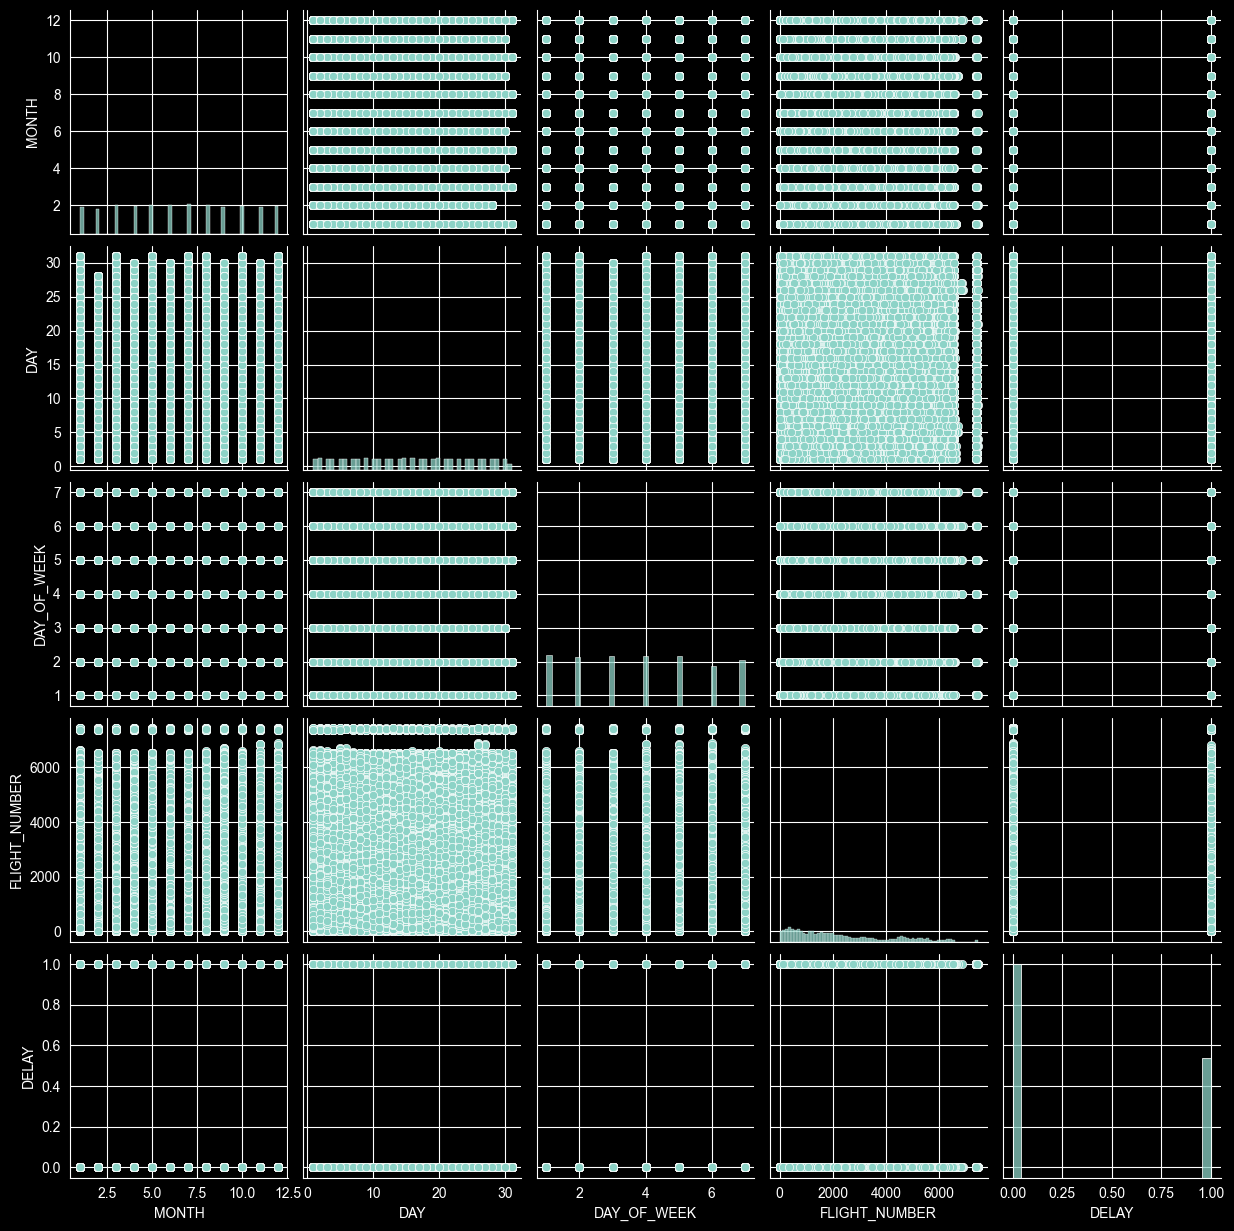

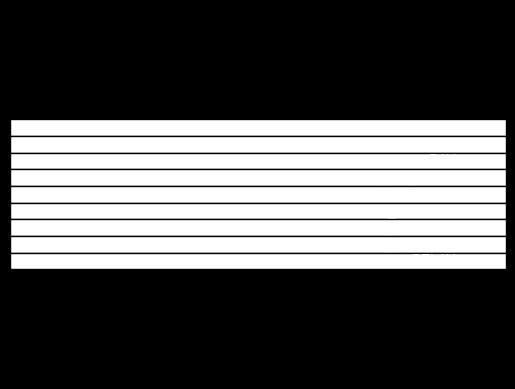

In [2]:
def plot_dataset(dataset: pd.DataFrame) -> None:
    new_df = dataset.copy()

    sns.pairplot(new_df)
    plt.show()

    plt.table(
        cellText=[[col] for col in dataset.columns],
        colLabels=["Columns"],
        loc="center"
    )
    plt.axis("off")
    plt.show()


plot_dataset(ds_flights_classification)

### Train / Test / Split

In [3]:
def tts(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    Y = df['DELAY']
    X = df.drop(columns=["DELAY"])

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = tts(ds_flights_classification)


X_train_reg, X_test_reg, y_train_reg, y_test_reg = tts(ds_flights_regression)

### Create Transformer to transform text to numeric Data

In [4]:
def transform_text_data() -> ColumnTransformer:
    categorical_cols = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])

    transformer = ColumnTransformer(transformers=[
        ("cat_transformer", categorical_transformer, categorical_cols),
    ])

    return transformer

### 1 Train the modell Decision Tree -> Found Accuracy 0.64

In [8]:

def train_decision_tree(X_train, y_train, X_test, y_test):
    preprocess = Pipeline(steps=[
        ("transform", transform_text_data()),
        ("normalizer", Normalizer())
    ])

    model = Pipeline(steps=[
        ('preprocess', preprocess),
        ('regression', DecisionTreeClassifier())
    ])


    param_grid = {
        "regression__criterion": ["gini", "entropy", "log_loss"],
        "regression__max_depth": [None, 2, 3, 5, 10, 15, 20, 30, 50],
        "regression__min_samples_split": [2,  50],
        "regression__min_samples_leaf": [1, 20],
    }
    gs = GridSearchCV(model, param_grid, cv=2)
    gs.fit(X_train, y_train)
    #model.fit(X_train, y_train)

    print(gs.best_score_)
    return gs.best_estimator_

best_decision_tree = train_decision_tree(X_train, y_train, X_test, y_test)
print(best_decision_tree)

0.64105
Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('transform',
                                  ColumnTransformer(transformers=[('cat_transformer',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('encoder',
                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                   ['AIRLINE',
                                                                    'ORIGIN_AIRPORT',
                                                                    'DESTINATION_AIRPORT'])])),
                                 ('normalizer', Normalizer())])),
                ('regression',
                 DecisionTr

### 2 Train the Modell - LogisitcRegression

In [6]:
def train_logistic_regression(X_train, y_train, X_test, y_test):

    preprocess = Pipeline(steps=[
        ("transform", transform_text_data()),
        ("normalizer", Normalizer())
    ])

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("regression", LogisticRegression(max_iter=1000))
    ])

    param_grid = {
        "regression__C": [0.01, 0.1, 1, 10, 100],
    }

    gs = GridSearchCV(model, param_grid, cv=2)
    gs.fit(X_train, y_train)

    print("Best CV Score:", gs.best_score_)
    print("Best Params:", gs.best_params_)

    y_train_pred = gs.predict(X_train)
    y_test_pred = gs.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    print("Train MAE:", train_mae)
    print("Test MAE:", test_mae)

    plt.figure(figsize=(6, 4))
    plt.bar(["Train MAE", "Test MAE"], [train_mae, test_mae])
    plt.ylabel("Mean Absolute Error")
    plt.title("Logistic Regression MAE")
    plt.show()

#train_logistic_regression(X_train_reg, y_train_reg, X_test_reg, y_test_reg)

### Boosting with Decission Tree

In [9]:
def train_with_boosting(X_train, y_train, X_test, y_test):
    preprocess = Pipeline(steps=[
        ("transform", transform_text_data()),
        ("normalizer", Normalizer())
    ])

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("classifier", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=10, min_samples_leaf=20),
            random_state=42
        ))
    ])

    param_grid = {
        "classifier__n_estimators": [50, 100, 200],
        "classifier__learning_rate": [0.01, 0.1, 0.5, 1.0],
        "classifier__estimator__max_depth": [1, 2, 3],
        "classifier__estimator__min_samples_leaf": [1, 5, 10],
    }

    gs = GridSearchCV(
        model,
        param_grid,
        cv=2,
        scoring="accuracy",
        n_jobs=-1
    )

    gs.fit(X_train, y_train)

    print("Best CV score:", gs.best_score_)
    print("Best params:", gs.best_params_)

    y_pred = gs.predict(X_test)
    print("Test accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))

train_with_boosting(X_train, y_train, X_test, y_test)

Best CV score: 0.6408750000000001
Best params: {'classifier__estimator__max_depth': 2, 'classifier__estimator__min_samples_leaf': 1, 'classifier__learning_rate': 1.0, 'classifier__n_estimators': 200}
Test accuracy: 0.63685
              precision    recall  f1-score   support

       False       0.64      1.00      0.78     12735
        True       1.00      0.00      0.00      7265

    accuracy                           0.64     20000
   macro avg       0.82      0.50      0.39     20000
weighted avg       0.77      0.64      0.50     20000



### Boosting with multiple Clasifier

In [14]:
def train_with_boosting_knn(X_train, y_train, X_test, y_test):
    preprocess = Pipeline(steps=[
        ("transform", transform_text_data()),
        ("normalizer", Normalizer())
    ])

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("classifier", AdaBoostClassifier(random_state=42))
    ])

    param_grid = {
        "classifier__estimator": [KNeighborsClassifier(), DecisionTreeClassifier(), RandomForestClassifier(), GaussianProcessClassifier()],
    }

    gs = GridSearchCV(
        model,
        param_grid,
        cv=2,
        scoring="accuracy",
        n_jobs=-1
    )

    gs.fit(X_train, y_train)

    print("Best CV score:", gs.best_score_)
    print("Best params:", gs.best_params_)

    y_pred = gs.predict(X_test)
    print("Test accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))

#train_with_boosting_knn(X_train, y_train, X_test, y_test)

/Users/julianfink/Documents/Coding/CAS26/uni_project/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
4 fits failed out of a total of 8.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/julianfink/Documents/Coding/CAS26/uni_project/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/julianfink/Documents/Coding/CAS26/uni_project/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *arg

Best CV score: 0.6075375000000001
Best params: {'classifier__estimator': DecisionTreeClassifier()}
Test accuracy: 0.6166
              precision    recall  f1-score   support

       False       0.65      0.86      0.74     12735
        True       0.44      0.19      0.26      7265

    accuracy                           0.62     20000
   macro avg       0.54      0.52      0.50     20000
weighted avg       0.57      0.62      0.57     20000



### Boosting with Decision Tree

In [46]:
def train_with_boosting_dectree(X_train, y_train, X_test, y_test):

    preprocess = Pipeline(steps=[
        ("transform", transform_text_data()),
        ("normalizer", Normalizer())
       # ("svd", TruncatedSVD(random_state=42))
    ])

    model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42
    )),
])

    param_grid = {
        "classifier__n_estimators": [50, 100, 200],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.5],
        "classifier__estimator__max_depth": [2, 3, 4],
    }

    gs = GridSearchCV(
        model,
        param_grid,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=1
    )

    gs.fit(X_train, y_train)

    print("Best CV score:", gs.best_score_)
    print("Best params:", gs.best_params_)

    y_pred = gs.predict(X_test)

    print("Test accuracy:", accuracy_score(y_test, y_pred))
    print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))


train_with_boosting_dectree(X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV score: 0.3948601138085006
Best params: {'classifier__estimator__max_depth': 4, 'classifier__learning_rate': 0.5, 'classifier__n_estimators': 200}
Test accuracy: 0.63655
Balanced accuracy: 0.5002568099630592
              precision    recall  f1-score   support

       False       0.64      1.00      0.78     12735
        True       0.44      0.00      0.00      7265

    accuracy                           0.64     20000
   macro avg       0.54      0.50      0.39     20000
weighted avg       0.56      0.64      0.50     20000

